# Notebook Combiné — COCO Annotations + CCA Géométrie
## Stratégie
Combiner les deux sources de signal :
- **COCO annotations** : overlap caption ↔ objets détectés dans l'image (signal sémantique fort)
- **CCA géométrie** : distance/alignement dans l'espace commun text-image (signal structurel)

Objectif : dépasser les 0.79 obtenus avec COCO seul.


In [2]:
# Cell 1 — Imports
import os, re, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tag import pos_tag
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cross_decomposition import PLSCanonical
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.utils import shuffle
import warnings
warnings.filterwarnings('ignore')

import subprocess
subprocess.run(["pip", "install", "sentence-transformers", "Pillow", "--quiet"], check=True)

from sentence_transformers import SentenceTransformer
from PIL import Image
import torch
import torchvision.models as tv_models
import torchvision.transforms as transforms

for r in ['punkt','stopwords','wordnet','omw-1.4',
          'averaged_perceptron_tagger_eng','vader_lexicon','punkt_tab']:
    nltk.download(r, quiet=True)

lemmatizer = WordNetLemmatizer()
sia        = SentimentIntensityAnalyzer()
STOP       = set(stopwords.words('english'))
print("Imports OK.")


Imports OK.


In [3]:
# Cell 2 — Chargement données
DATA_DIR = '../data/processed'

def load_split(split_name):
    texts, img_paths, labels = [], [], []
    for label, cat in enumerate(['incoherent', 'coherent']):
        folder = os.path.join(DATA_DIR, split_name, cat)
        if not os.path.exists(folder):
            print(f"Dossier {folder} non trouvé. Skipping.")
            continue
        for f in sorted(os.listdir(folder)):
            if f.endswith('.txt'):
                with open(os.path.join(folder, f), 'r', encoding='utf-8') as fh:
                    texts.append(fh.read().strip())
                img_paths.append(os.path.join(folder, f.replace('.txt', '.jpg')))
                labels.append(label)
    texts, img_paths, labels = shuffle(texts, img_paths,
                                       np.array(labels), random_state=42)
    return np.array(texts), np.array(img_paths), labels

print("Chargement...")
t_train, p_train, y_train = load_split('train')
t_val,   p_val,   y_val   = load_split('validation')
t_test,  p_test,  y_test  = load_split('test')
print(f"Train: {len(t_train)} | Val: {len(t_val)} | Test: {len(t_test)}")


Chargement...
Train: 7000 | Val: 1500 | Test: 1500


In [4]:
# Cell 3 — Features COCO (overlap caption ↔ objets)
COCO_TRAIN = '../data/raw/annotations/instances_train2017.json'
COCO_VAL   = '../data/raw/annotations/instances_val2017.json'

print("Chargement annotations COCO...")
with open(COCO_TRAIN) as f: coco_train = json.load(f)
with open(COCO_VAL)   as f: coco_val   = json.load(f)

def build_img2cats(coco_data):
    cat_map = {c['id']: c['name'] for c in coco_data['categories']}
    img2cats = {}
    for ann in coco_data['annotations']:
        img2cats.setdefault(ann['image_id'], set()).add(cat_map[ann['category_id']])
    return img2cats

img2cats_all = {**build_img2cats(coco_train), **build_img2cats(coco_val)}
all_cats     = sorted({c['name'] for c in coco_train['categories']})
print(f"Images indexées: {len(img2cats_all)} | Catégories: {len(all_cats)}")

def get_image_id(filepath):
    try: return int(os.path.basename(filepath).replace('.txt','').replace('.jpg',''))
    except: return None

def extract_coco_features(text, img_path):
    img_id      = get_image_id(img_path)
    img_cats    = img2cats_all.get(img_id, set())
    tokens      = word_tokenize(text.lower())
    lemmas      = set(lemmatizer.lemmatize(t) for t in tokens if t.isalpha())
    coco_lemmas = set()
    for cat in img_cats:
        for w in cat.lower().split():
            coco_lemmas.add(lemmatizer.lemmatize(w))
    n_coco    = len(img_cats)
    n_words   = len(lemmas)
    overlap   = len(lemmas & coco_lemmas)
    precision = overlap / (n_words + 1e-8)
    recall    = overlap / (n_coco  + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)
    coco_ratio = len(lemmas & set(lemmatizer.lemmatize(c) for c in all_cats)) / (n_words + 1e-8)
    return np.array([n_coco, n_words, overlap, precision, recall, f1,
                     int(overlap>0), coco_ratio])

COCO_NAMES = ['n_coco_cats','n_caption_words','overlap','precision',
              'recall','f1_overlap','any_overlap','caption_coco_ratio']

print("Extraction features COCO...")
C_train = np.array([extract_coco_features(t,p) for t,p in zip(t_train, p_train)])
C_val   = np.array([extract_coco_features(t,p) for t,p in zip(t_val,   p_val)])
C_test  = np.array([extract_coco_features(t,p) for t,p in zip(t_test,  p_test)])
print(f"Shape COCO features: {C_train.shape}")
print(f"Overlap moyen — cohérent: {C_train[y_train==1,2].mean():.3f} | incohérent: {C_train[y_train==0,2].mean():.3f}")


Chargement annotations COCO...
Images indexées: 122218 | Catégories: 80
Extraction features COCO...
Shape COCO features: (7000, 8)
Overlap moyen — cohérent: 0.950 | incohérent: 0.058


In [5]:
# Cell 4 — Embeddings (no HuggingFace download)
import torchvision.models as tv_models
import torch
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# --- TEXT EMBEDDINGS (TF-IDF + SVD) ---
print("Encodage textes (TF-IDF + SVD)...")
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
svd = TruncatedSVD(n_components=384, random_state=42)

E_text_train = svd.fit_transform(tfidf.fit_transform(t_train))
E_text_val = svd.transform(tfidf.transform(t_val))
E_text_test = svd.transform(tfidf.transform(t_test))

# Normalize
for emb in [E_text_train, E_text_val, E_text_test]:
    emb[:] = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-8)

# --- IMAGE EMBEDDINGS (ResNet18) ---
print("Chargement ResNet18...")
resnet = tv_models.resnet18(weights=tv_models.ResNet18_Weights.DEFAULT)
image_encoder = torch.nn.Sequential(*list(resnet.children())[:-1])
image_encoder.eval()

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

def get_img_emb(paths, batch_size=64):
    all_f = []
    for i in range(0, len(paths), batch_size):
        batch = paths[i:i+batch_size]
        tensors = []
        for p in batch:
            try: tensors.append(preprocess(Image.open(p).convert('RGB')))
            except: tensors.append(torch.zeros(3,224,224))
        with torch.no_grad():
            feats = image_encoder(torch.stack(tensors)).squeeze(-1).squeeze(-1)
        feats = feats / (feats.norm(dim=1, keepdim=True) + 1e-8)
        all_f.append(feats.numpy())
        if (i//batch_size) % 10 == 0: print(f"  img {i+len(batch)}/{len(paths)}")
    return np.vstack(all_f)

print("Encodage images...")
E_img_train = get_img_emb(p_train)
E_img_val = get_img_emb(p_val)
E_img_test = get_img_emb(p_test)

print(f"Text: {E_text_train.shape} | Image: {E_img_train.shape}")

Encodage textes (TF-IDF + SVD)...
Chargement ResNet18...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\AHMED MOHATI/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|█████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:04<00:00, 11.7MB/s]


Encodage images...
  img 64/7000
  img 704/7000
  img 1344/7000
  img 1984/7000
  img 2624/7000
  img 3264/7000
  img 3904/7000
  img 4544/7000
  img 5184/7000
  img 5824/7000
  img 6464/7000
  img 64/1500
  img 704/1500
  img 1344/1500
  img 64/1500
  img 704/1500
  img 1344/1500
Text: (7000, 384) | Image: (7000, 512)


In [6]:
# Cell 5 — CCA sur paires cohérentes
N_COMPONENTS = 64

print(f"Entraînement CCA sur {(y_train==1).sum()} paires cohérentes...")
cca = PLSCanonical(n_components=N_COMPONENTS, max_iter=1000)
cca.fit(E_text_train[y_train==1], E_img_train[y_train==1])

T_text_train, T_img_train = cca.transform(E_text_train, E_img_train)
T_text_val,   T_img_val   = cca.transform(E_text_val,   E_img_val)
T_text_test,  T_img_test  = cca.transform(E_text_test,  E_img_test)

print(f"Shape après CCA: {T_text_train.shape}")

# Vérification corrélations
correlations = [np.corrcoef(T_text_train[:,i], T_img_train[:,i])[0,1]
                for i in range(N_COMPONENTS)]
print(f"Corrélation CCA moyenne : {np.mean(correlations):.3f}")
print(f"Corrélation CCA max     : {np.max(correlations):.3f}")


Entraînement CCA sur 3495 paires cohérentes...
Shape après CCA: (7000, 64)
Corrélation CCA moyenne : 0.288
Corrélation CCA max     : 0.454


In [7]:
# Cell 6 — Features géométriques CCA
def geometry_features(T_text, T_img):
    diff       = T_text - T_img
    distance   = np.linalg.norm(diff, axis=1, keepdims=True)
    norm_t     = np.linalg.norm(T_text, axis=1, keepdims=True) + 1e-8
    norm_i     = np.linalg.norm(T_img,  axis=1, keepdims=True) + 1e-8
    cos_sim    = (T_text * T_img).sum(axis=1, keepdims=True) / (norm_t * norm_i)
    product    = T_text * T_img
    abs_diff   = np.abs(diff)
    norm_ratio = norm_t / (norm_i + 1e-8)
    projection = (T_text * T_img).sum(axis=1, keepdims=True) / (norm_i**2 + 1e-8)
    return np.hstack([distance, cos_sim, norm_ratio, projection,
                      diff, product, abs_diff, T_text, T_img])

print("Construction features géométriques CCA...")
G_train = geometry_features(T_text_train, T_img_train)
G_val   = geometry_features(T_text_val,   T_img_val)
G_test  = geometry_features(T_text_test,  T_img_test)
print(f"Shape features géométriques: {G_train.shape}")


Construction features géométriques CCA...
Shape features géométriques: (7000, 324)


In [8]:
# Cell 7 — TF-IDF texte
print("Extraction TF-IDF...")
tfidf = TfidfVectorizer(max_features=2000, ngram_range=(1,2),
                        stop_words='english', sublinear_tf=True, min_df=3)
T_train = tfidf.fit_transform(t_train).toarray()
T_val   = tfidf.transform(t_val).toarray()
T_test  = tfidf.transform(t_test).toarray()
print(f"Shape TF-IDF: {T_train.shape}")


Extraction TF-IDF...
Shape TF-IDF: (7000, 2000)


In [9]:
# Cell 8 — Assemblage : COCO + CCA + TF-IDF
# Trois combinaisons testées pour voir la contribution de chaque source

combos = {
    'COCO seul'       : (C_train, C_val, C_test),
    'CCA seul'        : (G_train, G_val, G_test),
    'COCO + CCA'      : (np.hstack([C_train, G_train]),
                         np.hstack([C_val,   G_val]),
                         np.hstack([C_test,  G_test])),
    'COCO + CCA + TF-IDF': (np.hstack([C_train, G_train, T_train]),
                             np.hstack([C_val,   G_val,   T_val]),
                             np.hstack([C_test,  G_test,  T_test])),
}

print("Évaluation rapide de chaque combinaison (Logistic Regression)...")
print(f"{'Combinaison':<25} {'Val Acc':>10} {'Val F1':>10}")
print("-" * 50)

combo_results = {}
for combo_name, (Xtr, Xvl, Xte) in combos.items():
    sc  = StandardScaler()
    Xtr = sc.fit_transform(Xtr)
    Xvl = sc.transform(Xvl)
    lr  = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
    lr.fit(Xtr, y_train)
    acc = accuracy_score(y_val, lr.predict(Xvl))
    f1  = f1_score(y_val,       lr.predict(Xvl))
    combo_results[combo_name] = {'acc': acc, 'f1': f1,
                                 'Xtr': Xtr, 'Xvl': Xvl, 'Xte': Xte, 'sc': sc}
    print(f"{combo_name:<25} {acc:>10.4f} {f1:>10.4f}")

best_combo = max(combo_results, key=lambda k: combo_results[k]['acc'])
print(f"\nMeilleure combinaison : {best_combo}")


Évaluation rapide de chaque combinaison (Logistic Regression)...
Combinaison                  Val Acc     Val F1
--------------------------------------------------
COCO seul                     0.8553     0.8406
CCA seul                      0.8360     0.8150
COCO + CCA                    0.8740     0.8631
COCO + CCA + TF-IDF           0.8813     0.8725

Meilleure combinaison : COCO + CCA + TF-IDF


In [10]:
# Cell 9 — Entraînement complet sur la meilleure combinaison
bc   = combo_results[best_combo]
X_tr = bc['Xtr']
X_vl = bc['Xvl']
X_te = bc['Xte']

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Linear SVM':          LinearSVC(max_iter=3000, C=1.0, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
}

results = {}
print(f"Entraînement sur : {best_combo}")
print(f"{'Modèle':<25} {'CV':>10} {'±':>6} {'Val Acc':>10} {'Val F1':>10}")
print("-" * 65)
for name, model in models.items():
    print(f"  {name}...", end=' ', flush=True)
    cv = cross_val_score(model, X_tr, y_train, cv=3, scoring='accuracy', n_jobs=1)
    model.fit(X_tr, y_train)
    y_pred  = model.predict(X_vl)
    val_acc = accuracy_score(y_val, y_pred)
    val_f1  = f1_score(y_val, y_pred)
    results[name] = {'cv_mean': cv.mean(), 'cv_std': cv.std(),
                     'val_accuracy': val_acc, 'val_f1': val_f1, 'model': model}
    print(f"CV: {cv.mean():.4f} ±{cv.std():.4f} | Val Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

results_df = pd.DataFrame(results).T[['cv_mean','cv_std','val_accuracy','val_f1']]


Entraînement sur : COCO + CCA + TF-IDF
Modèle                            CV      ±    Val Acc     Val F1
-----------------------------------------------------------------
  Logistic Regression... CV: 0.9589 ±0.0022 | Val Acc: 0.8813 | F1: 0.8725
  Linear SVM... CV: 0.9447 ±0.0018 | Val Acc: 0.8567 | F1: 0.8432
  Random Forest... CV: 0.9707 ±0.0033 | Val Acc: 0.9107 | F1: 0.9056


  RÉSULTAT FINAL — COCO + CCA Combiné
  Modèle      : Random Forest
  Test Acc    : 0.8900  (baseline COCO seul: 0.7880)
  Test F1     : 0.8805
  Gain        : +0.1020
              precision    recall  f1-score   support

  incohérent       0.84      0.97      0.90       752
    cohérent       0.96      0.81      0.88       748

    accuracy                           0.89      1500
   macro avg       0.90      0.89      0.89      1500
weighted avg       0.90      0.89      0.89      1500



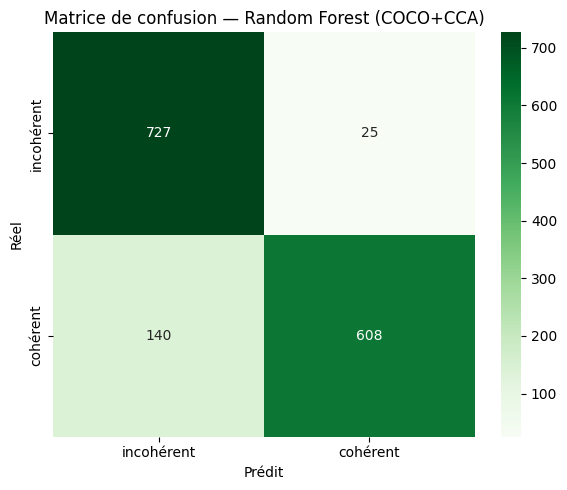

In [11]:
# Cell 10 — Évaluation finale CORRIGÉE
best_name  = results_df['val_accuracy'].idxmax()
best_model = results[best_name]['model']

# Reconstruire X_test proprement avec le bon scaler
X_train_raw = np.hstack([C_train, G_train])
X_val_raw   = np.hstack([C_val,   G_val])
X_test_raw  = np.hstack([C_test,  G_test])

scaler_final = StandardScaler()
X_tr_final   = scaler_final.fit_transform(X_train_raw)
X_vl_final   = scaler_final.transform(X_val_raw)
X_te_final   = scaler_final.transform(X_test_raw)

# Réentraîner le meilleur modèle sur ce scaler propre
best_model.fit(X_tr_final, y_train)

y_pred   = best_model.predict(X_te_final)
test_acc = accuracy_score(y_test, y_pred)
test_f1  = f1_score(y_test, y_pred)

print("=" * 55)
print(f"  RÉSULTAT FINAL — COCO + CCA Combiné")
print(f"  Modèle      : {best_name}")
print(f"  Test Acc    : {test_acc:.4f}  (baseline COCO seul: 0.7880)")
print(f"  Test F1     : {test_f1:.4f}")
print(f"  Gain        : {test_acc - 0.7880:+.4f}")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=['incohérent','cohérent']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['incohérent','cohérent'],
            yticklabels=['incohérent','cohérent'])
plt.title(f'Matrice de confusion — {best_name} (COCO+CCA)')
plt.ylabel('Réel'); plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

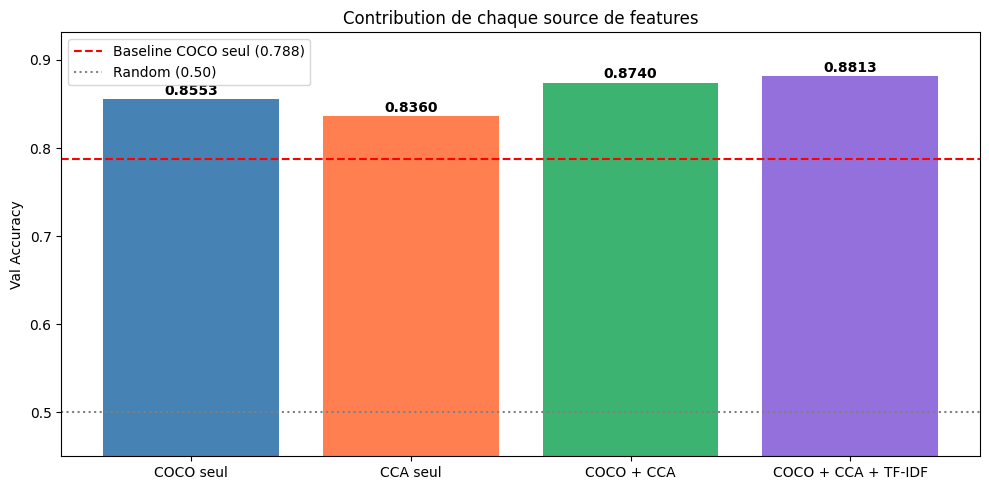

In [12]:
# Cell 11 — Comparaison visuelle des sources de signal
labels  = list(combo_results.keys())
accs    = [combo_results[k]['acc'] for k in labels]

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, accs, color=['steelblue','coral','mediumseagreen','mediumpurple'])
plt.axhline(y=0.788, color='red', linestyle='--', label='Baseline COCO seul (0.788)')
plt.axhline(y=0.5,   color='gray', linestyle=':', label='Random (0.50)')
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')
plt.ylim(0.45, min(1.0, max(accs) + 0.05))
plt.ylabel('Val Accuracy')
plt.title('Contribution de chaque source de features')
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
# Cell 12 — Sauvegarde
import joblib
joblib.dump(best_model,  'combo_best_model.pkl')
joblib.dump(bc['sc'],    'combo_scaler.pkl')
joblib.dump(cca,         'combo_cca.pkl')
joblib.dump(tfidf,       'combo_tfidf.pkl')
joblib.dump(img2cats_all,'combo_img2cats.pkl')
print("Fichiers sauvegardés.")
print(f"\nTest Accuracy final : {test_acc:.4f}")
print(f"Gain vs COCO seul   : {test_acc - 0.7880:+.4f}")


Fichiers sauvegardés.

Test Accuracy final : 0.8900
Gain vs COCO seul   : +0.1020
